In [2]:
import netrd
import networkx as nx
import random
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import adjusted_mutual_info_score
import seaborn as sns
from itertools import combinations
from binascii import crc32
import math

# monkey patch numpy to support old netrd code
if not hasattr(np, 'float'):
    np.float = float

q1 - Network Reconstruction

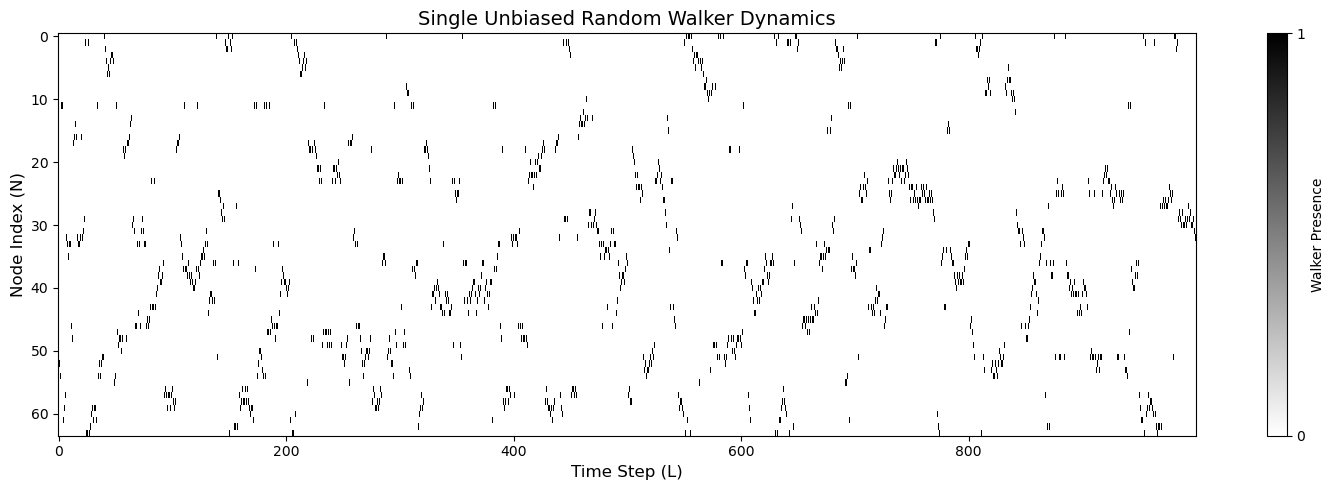

In [2]:
G = nx.watts_strogatz_graph(64, 4, .25)

# --- run sim ---

model = netrd.dynamics.SingleUnbiasedRandomWalker()
sim_results = {}
available = list(G.nodes())
for i in range(20):
    seed = random.choice(available)
    tseries = model.simulate(G, 1000, seed)
    H = model.results['ground_truth']
    sim_results[seed] = (tseries, H)
    available.remove(seed)

# --- visualize 1st time-series matrix ---

# retrieve 1st element from 1st tuple
mat_to_show = next(iter(sim_results.values()))[0]

# plot
plt.figure(figsize=(15, 5))
plt.imshow(mat_to_show, 
           aspect='auto',
           cmap='binary',
           interpolation='none')

# aesthetics
plt.colorbar(label='Walker Presence', ticks=[0, 1])
plt.title('Single Unbiased Random Walker Dynamics', fontsize=14)
plt.xlabel('Time Step (L)', fontsize=12)
plt.ylabel('Node Index (N)', fontsize=12)

plt.tight_layout()
#plt.savefig('imgs/randwalk_timeseries.png')

In [27]:
# --- reconstruction ---

recon = netrd.reconstruction.GrangerCausality()

# loop
recon_results = {}
for seed, (tseries, H) in sim_results.items():
    G_recon = recon.fit(tseries)
    recon_results[seed] = (G_recon, H)

# custom threshold version
recon_results_thr = {}
for seed, (tseries, H) in sim_results.items():
    G_recon = recon.fit(tseries, threshold_type='degree', avg_k=4)
    recon_results_thr[seed] = (G_recon, H)

c:\Users\User\anaconda3\envs\school\lib\site-packages\netrd\utilities\threshold.py:40: RuntimeWarning: Setting 'cutoffs' argument is strongly encouraged. Using cutoff range of (-1, 1).
  warnings.warn(
c:\Users\User\anaconda3\envs\school\lib\site-packages\netrd\utilities\threshold.py:40: RuntimeWarning: Setting 'cutoffs' argument is strongly encouraged. Using cutoff range of (-1, 1).
  warnings.warn(
c:\Users\User\anaconda3\envs\school\lib\site-packages\netrd\utilities\threshold.py:40: RuntimeWarning: Setting 'cutoffs' argument is strongly encouraged. Using cutoff range of (-1, 1).
  warnings.warn(
c:\Users\User\anaconda3\envs\school\lib\site-packages\netrd\utilities\threshold.py:40: RuntimeWarning: Setting 'cutoffs' argument is strongly encouraged. Using cutoff range of (-1, 1).
  warnings.warn(
c:\Users\User\anaconda3\envs\school\lib\site-packages\netrd\utilities\threshold.py:40: RuntimeWarning: Setting 'cutoffs' argument is strongly encouraged. Using cutoff range of (-1, 1).
  warni

C:\Users\User\AppData\Local\Temp\ipykernel_2364\1587449824.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=seeds,


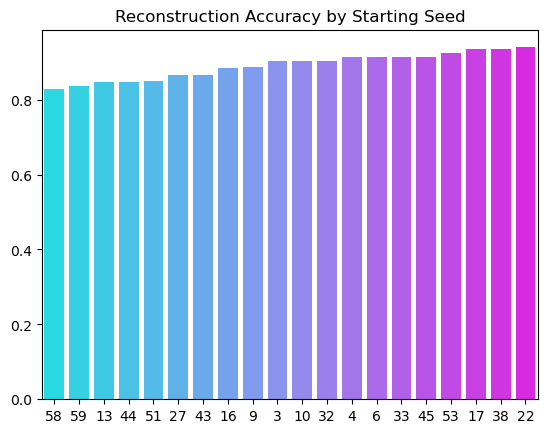

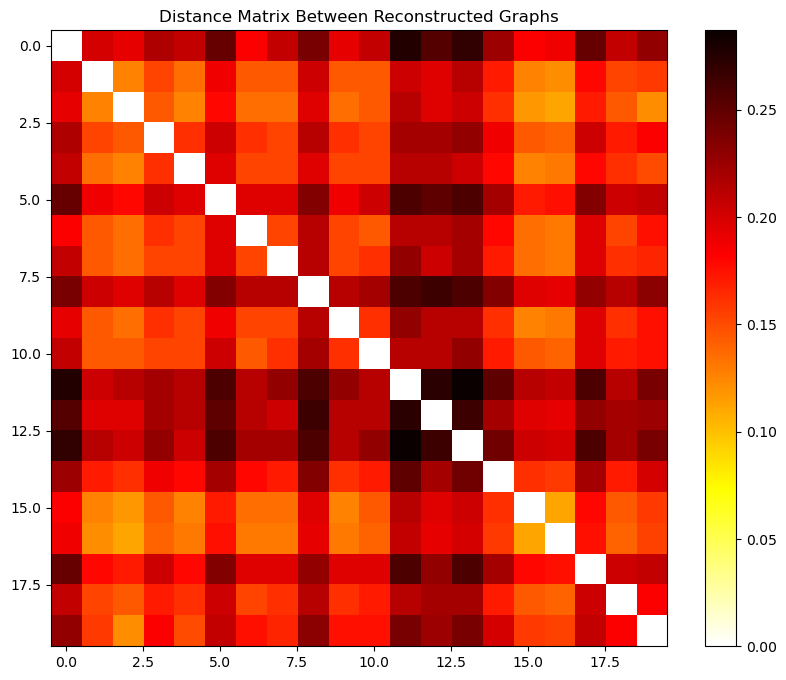

In [ ]:
# --- evaluation (d-f) ---

# AMI function for graph similarity
def graph_ami(G1, G2):
    # converting to matrices and flattening for function
    adj1 = nx.to_numpy_array(G1).flatten()
    adj2 = nx.to_numpy_array(G2).flatten()

    # binarize both matrices (float -> bool -> int)
    adj1 = (adj1 > 0).astype(int)
    adj2 = (adj2 > 0).astype(int)

    return adjusted_mutual_info_score(adj1, adj2)

# create comparison list of G/R tuples and evaluate
comparison_pairs = list(recon_results_thr.values())
seeds=list(recon_results_thr.keys())
scores = []
for R, G in comparison_pairs:
    score = graph_ami(R, G)
    scores.append(score)

# plotting
ordering = [label for _, label in sorted(zip(scores, seeds))]
sns.barplot(x=seeds,
            y=scores,
            palette='cool',
            order=ordering)
plt.title('Reconstruction Accuracy by Starting Seed')
plt.savefig('imgs/reconstruction_performance_barplot.png')
plt.show()

# --- R-R pairs (part e) ---

Rs = [pair[0] for pair in comparison_pairs]

# init matrix
n = len(Rs)
dist_mat = np.zeros((n,n))

r_pairs = list(combinations(range(n), 2))
for r1, r2 in r_pairs:
    score = graph_ami(Rs[r1], Rs[r2])
    dist = 1 - score
    # fill matrix on both sides
    dist_mat[r1, r2] = dist
    dist_mat[r2, r1] = dist

# plotting
plt.figure(figsize=(10, 8))
plt.imshow(dist_mat, cmap='hot_r') # reversed for distance
plt.colorbar()
plt.title("Distance Matrix Between Reconstructed Graphs")
plt.savefig('imgs/reconstructed_comb_heatmap.png')
plt.show()

q2 - Big Data

In [ ]:
# --- create bloom filter ---

def bloomFilter(n, err):
    ''' 
    Initializes an empty bloom filter with desired parameters.

    Args
    ---
    n : (int) Number of elements
    err : (float) : Desired error rate

    Returns
    ---
    NDArray : Empty filter
    int: Ideal number of hash functions
    '''
    # formulas for m and k
    k = int(-(math.log2(err)))
    m = int(-(n*math.log(err)) / (math.log(2))**2)

    return np.zeros(m, dtype=int), k

def add_to_bloom(edges, filter_output):
    ''' 
    Adds a set of edges to an empty bloom filter.
    '''
    filter, k = filter_output
    m = len(filter) # m is the size of the filter

    # single hash function repeated with slight variations of the edge (extra "index" element)
    # in an order that remains consistent in lookup (same as notebook)
    def bloomHash(edge, i):
        return hash(tuple([i, *edge])) # concise tuple -> list -> tuple conversion
    
    for edge in edges:
        for i in range(k): # run k times
            # modulo operation to wrap the massive number into one of m index slots
            bin_ = bloomHash(edge, i) % m
            filter[bin_] = 1 # set indices to 1

    return filter

# --- add to filter ---

G = nx.erdos_renyi_graph(1000, 0.05)
edges = list(G.edges())
edgenum = len(edges)

# test values of n
n_trials = {}
for n in [edgenum, edgenum*1.5, edgenum*2, edgenum*3]:
    emptyfilt = bloomFilter(n, 0.05)
    filt = add_to_bloom(edges, emptyfilt)
    n_trials[n] = filt

# check filter performance
